In [47]:
import numpy as np
import os
from pathlib import Path
import time
import h5py
from datetime import datetime
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import e, m_p
import pandas as pd

import xtrack as xt
import xpart as xp
import xobjects as xo
import xfields as xf

from cpymad.madx import Madx

from PyBE.gaussian import get_field

In [48]:
slices = 4
folder = Path('Lattice_Files/02_Aperture_Lattice/')

madx = Madx(stdout=False)
madx.call(str(folder / 'ISIS.injected_beam'))
madx.call(str(folder / 'ISIS.elements'))
madx.call(str(folder / 'ISIS.strength'))
madx.call(str(folder / 'ISIS.sequence'))
madx.call(str(folder / 'ISIS.aperture'))
madx.use('synchrotron')
madx.command.select(flag='makethin', slice=slices, thick=False)
madx.command.makethin(sequence='synchrotron', style='teapot', makedipedge=True)

line = xt.Line.from_madx_sequence(madx.sequence.synchrotron, install_apertures=True)

Converting sequence "synchrotron":   0%|          | 0/1990 [00:00<?, ?it/s]

In [49]:
n_macro_particles: int = 1000
nemitt_x_0: float = 1e-6
nemitt_y_0: float = 1e-6
p0c: float = 0.37033168 * 1e9

context = xo.ContextCpu(omp_num_threads=10)

line.set_particle_ref('proton', p0c=p0c)
twiss = line.twiss(method='4d', freeze_longitudinal=True,)

particles = line.build_particles(
    num_particles=n_macro_particles,
    x_norm=np.random.normal(size=n_macro_particles),
    y_norm=np.random.normal(size=n_macro_particles),
    px_norm=np.random.normal(size=n_macro_particles),
    py_norm=np.random.normal(size=n_macro_particles),
    nemitt_x=nemitt_x_0,
    nemitt_y=nemitt_y_0,
    method='4d',
    freeze_longitudinal=True,
    mode='normalized_transverse',
)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [50]:
beam_intensity = 5e9
n_interactions = 100

sigma_z_fake = 1e16 
circumference = line.get_length()
n_particles = beam_intensity/line.get_length()
n_particles_fake = n_particles * np.sqrt(2*np.pi)*sigma_z_fake

lprofile = xf.LongitudinalProfileQGaussian(
        number_of_particles= n_particles_fake,
        sigma_z= sigma_z_fake,
        z0= 0.,
        q_parameter= 1.0)


xf.install_spacecharge_frozen(
    line=line,
    longitudinal_profile=lprofile,
    nemitt_x=nemitt_x_0, 
    nemitt_y=nemitt_y_0,
    sigma_z=sigma_z_fake,
    num_spacecharge_interactions=n_interactions,
    delta_rms=0)

Creating spacecharge elements:   0%|          | 0/100 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/3980 [00:00<?, ?it/s]

In [51]:
coef = e/(particles.energy0*particles.beta0**2)

line.build_tracker(_context=context)

x = [particles.x.copy()]
y = [particles.y.copy()]
px = [particles.px.copy()]
py = [particles.py.copy()]

line.track(particles, ele_stop='spacecharge_0', freeze_longitudinal=True)
x.append(particles.x.copy())
y.append(particles.y.copy())
px.append(particles.px.copy())
py.append(particles.py.copy())

for i in range(n_interactions-1):
    print(i)
    spacecharge_element = line.elements[line.element_names.index(f'spacecharge_{i}')]
    l = spacecharge_element.length
    sigma_x = spacecharge_element.sigma_x
    sigma_y = spacecharge_element.sigma_y

    
    line.track(particles, ele_start=f'spacecharge_{i}', ele_stop=f'spacecharge_{i+1}')
    x.append(particles.x.copy())
    y.append(particles.y.copy())
    px.append(particles.px.copy())
    py.append(particles.py.copy())
    #Ex, Ey = get_field(particles.x, particles.y, sigma_x, sigma_y)
    #particles.px += coef * l * Ex
    #particles.py += coef * l * Ey

line.track(particles, ele_start=f'spacecharge_{n_interactions-1}', ele_stop=0, freeze_longitudinal=True)
x.append(particles.x.copy())
y.append(particles.y.copy())
px.append(particles.px.copy())
py.append(particles.py.copy())


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98


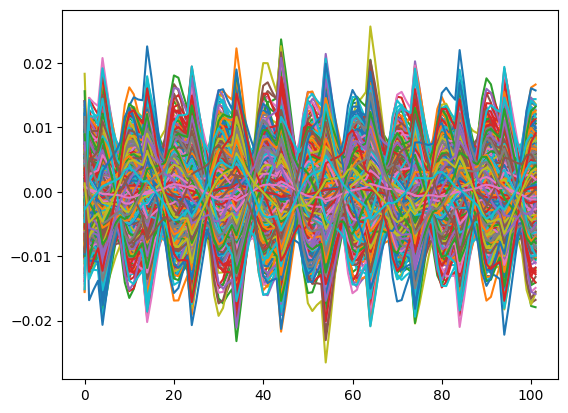

In [52]:
x = np.array(x).T
for particle in x:

    plt.plot(particle)
plt.show()

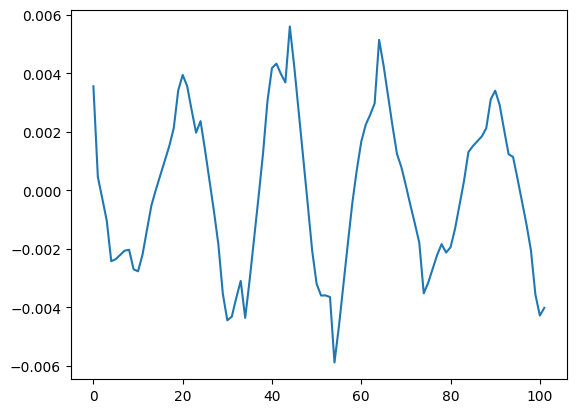

In [58]:
for i in range(1):
    plt.plot(x[i])
plt.show()

In [62]:
for i in range(len(line.elements)):
    if 'charge' in line.element_names[i]:
        print(line.elements[i])

View of SpaceChargeBiGaussian(longitudinal_profile=LongitudinalProfileQGaussian(number_of_particles=7.67e+23), fieldmap=BiGaussianFieldMap(mean_x=0, mean_y=0, sigma_x=0.00514, sigma_y=0.00389, min_sigma_diff=1e-10), length=1.63, z_kick_num_integ_per_sigma=np.int64(0), shift_x=0, shift_y=0, shift_s=0, rot_s_rad=0, rot_x_rad=0, rot_y_rad=0, rot_s_rad_no_frame=0, rot_shift_anchor=0)
View of SpaceChargeBiGaussian(longitudinal_profile=LongitudinalProfileQGaussian(number_of_particles=7.67e+23), fieldmap=BiGaussianFieldMap(mean_x=-1.07e-16, mean_y=0, sigma_x=0.00463, sigma_y=0.0052, min_sigma_diff=1e-10), length=1.63, z_kick_num_integ_per_sigma=np.int64(0), shift_x=0, shift_y=0, shift_s=0, rot_s_rad=0, rot_x_rad=0, rot_y_rad=0, rot_s_rad_no_frame=0, rot_shift_anchor=0)
View of SpaceChargeBiGaussian(longitudinal_profile=LongitudinalProfileQGaussian(number_of_particles=7.67e+23), fieldmap=BiGaussianFieldMap(mean_x=-2.25e-16, mean_y=0, sigma_x=0.00436, sigma_y=0.00654, min_sigma_diff=1e-10), len